Verificar Conda Env

In [1]:
import sys
import os

print("Ejecutable de Python actual:", sys.executable)
print("Entorno Conda activo:", os.environ.get("CONDA_DEFAULT_ENV"))
import cv2

img = cv2.imread('ant.png')
print(img.shape[0], img.shape[1], img.shape[2], len(img.shape))

Ejecutable de Python actual: c:\Users\angel\miniconda3\envs\tf-gpu\python.exe
Entorno Conda activo: tf-gpu
334 500 3 3


# Importar Librerías

In [2]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [3]:
import keras
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential,Model
from tensorflow.keras.layers import Input
from keras.layers import Dense, Dropout, Flatten
#from keras.layers import Conv2D, MaxPooling2D
#from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    BatchNormalization, SeparableConv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense, Conv2D
)
from keras.layers import LeakyReLU

from tensorflow.keras import mixed_precision

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print("Dispositivos Físicos:", tf.config.list_physical_devices("GPU"))
try:
    gpus = tf.config.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.set_memory_growth(gpu, True)
    print("Memoria GPU dinámica activada")
except:
    print("No se pudo configurar la memoria dinámica (o no hay GPU)")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 2060, compute capability 7.5
Dispositivos Físicos: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
No se pudo configurar la memoria dinámica (o no hay GPU)


# Cargar set de Imágenes

In [4]:
# Linux
# dirname = os.path.join(os.getcwd(),'./data/sportimages/')

# MacOS

# Windows for (2060 training)
dirname = os.path.join(os.getcwd(),'C:\\Users\\angel\\MyCode\\ITM-2025-IA\\projects\\20251015_cnn\\data')
imgpath = dirname + os.sep

images = []
directories = []
dircount = []
prevRoot=''
cant=0
image_size = 128

print("leyendo imagenes de ",imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    for filename in filenames:
        if re.search("\\.(jpg|jpeg|png|bmp|tiff)$", filename):
            cant=cant+1
            filepath = os.path.join(root, filename)
            image = plt.imread(filepath)
            if(len(image.shape)==3):
                images.append(image)
            b = "Leyendo..." + str(cant)
            print (b, end="\r")
            if prevRoot !=root:
                print(root, cant)
                prevRoot=root
                directories.append(root)
                dircount.append(cant)
                cant=0
dircount.append(cant)

dircount = dircount[1:]
dircount[0]=dircount[0]+1
print('Directorios leidos:',len(directories))
print("Imagenes en cada directorio", dircount)
print('suma Total de imagenes en subdirs:',sum(dircount))

leyendo imagenes de  C:\Users\angel\MyCode\ITM-2025-IA\projects\20251015_cnn\data\
C:\Users\angel\MyCode\ITM-2025-IA\projects\20251015_cnn\data\catarina 1
C:\Users\angel\MyCode\ITM-2025-IA\projects\20251015_cnn\data\gato 4773
C:\Users\angel\MyCode\ITM-2025-IA\projects\20251015_cnn\data\hormiga 10001
C:\Users\angel\MyCode\ITM-2025-IA\projects\20251015_cnn\data\perro 4998
C:\Users\angel\MyCode\ITM-2025-IA\projects\20251015_cnn\data\tortuga 10772
Directorios leidos: 5
Imagenes en cada directorio [4774, 10001, 4998, 10772, 3325]
suma Total de imagenes en subdirs: 33870


# Creamos las etiquetas

In [5]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ",len(labels))


Cantidad etiquetas creadas:  33870


In [6]:
clases=[]
indice=0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice , name[len(name)-1])
    clases.append(name[len(name)-1])
    indice=indice+1

0 catarina
1 gato
2 hormiga
3 perro
4 tortuga


In [7]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) #convierto de lista a numpy



# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  5
Output classes :  [0 1 2 3 4]


# Creamos Sets de Entrenamiento y Test

In [8]:
train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

Training data shape :  (27096, 128, 128, 3) (27096,)
Testing data shape :  (6774, 128, 128, 3) (6774,)


Text(0.5, 1.0, 'Ground Truth : 3')

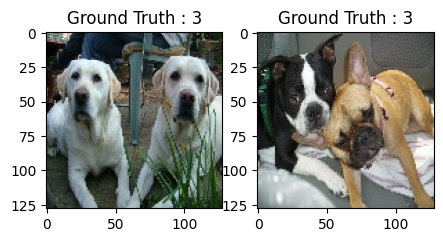

In [9]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

# Preprocesamos las imagenes

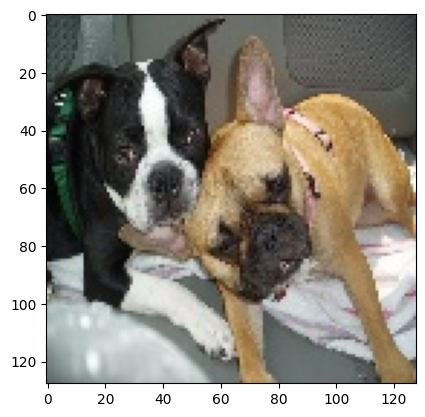

In [10]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X/255.
test_X = test_X/255.
plt.imshow(test_X[0,:,:])

## Hacemos el One-hot Encoding para la red

In [11]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 3
After conversion to one-hot: [0. 0. 0. 1. 0.]


# Creamos el Set de Entrenamiento y Validación

In [12]:
#Mezclar todo y crear los grupos de entrenamiento y testing
train_X,valid_X,train_label,valid_label = train_test_split(train_X, train_Y_one_hot, test_size=0.2, random_state=13)

In [13]:
print(train_X.shape,valid_X.shape,train_label.shape,valid_label.shape)
print("Total NaNs in train_X:", np.isnan(train_X).sum())
print("Total Infs in train_X:", np.isinf(train_X).sum())

(21676, 128, 128, 3) (5420, 128, 128, 3) (21676, 5) (5420, 5)
Total NaNs in train_X: 0
Total Infs in train_X: 0


# Creamos el modelo de CNN

In [14]:
#declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-3 # Valor inicial de learning rate. El valor 1e-3 corresponde con 0.001
epochs = 160 # Cantidad de iteraciones completas al conjunto de imagenes de entrenamiento
batch_size = 8 # cantidad de imágenes que se toman a la vez en memoria

In [15]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3),activation='linear',padding='same',input_shape=(image_size,image_size,3)))
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D((2, 2),padding='same'))

model.add(Conv2D(64, kernel_size=(3, 3),activation='linear',padding='same',))
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), padding='same', activation='linear'))
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(nClasses, activation='softmax'))

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 128, 128, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 64, 64, 64)        0         
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                    

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.SGD(learning_rate=INIT_LR), metrics=['accuracy'], run_eagerly=True, jit_compile=True)

# Entrenamos el modelo: Aprende a clasificar imágenes

In [18]:
# este paso puede tomar varios minutos, dependiendo de tu ordenador, cpu y memoria ram libre
train = model.fit(train_X, train_label, batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(valid_X, valid_label))

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

In [ ]:
# guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
model.save("./models/animales_e20.h5")

# Evaluamos la red

In [ ]:
test_eval = model.evaluate(test_X, test_Y_one_hot, verbose=1)

In [ ]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

In [ ]:
train.history

In [ ]:
accuracy = train.history['accuracy']
val_accuracy = train.history['val_accuracy']
loss = train.history['loss']
val_loss = train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
predicted_classes2 = model.predict(test_X)

In [ ]:
predicted_classes=[]
for predicted_sport in predicted_classes2:
    predicted_classes.append(predicted_sport.tolist().index(max(predicted_sport)))
predicted_classes=np.array(predicted_classes)

In [ ]:
predicted_classes.shape, test_Y.shape

# Aprendamos de los errores: Qué mejorar

In [ ]:
correct = np.where(predicted_classes==test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[correct].reshape(image_size,image_size,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(clases[predicted_classes[correct]],
                                                    clases[test_Y[correct]]))

    plt.tight_layout()

In [ ]:
incorrect = np.where(predicted_classes!=test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect].reshape(21,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(clases[predicted_classes[incorrect]],
                                                    clases[test_Y[incorrect]]))
    plt.tight_layout()

In [ ]:
target_names = ["Class {}".format(i) for i in range(nClasses)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))

In [ ]:
images=[]
# AQUI ESPECIFICAMOS UNAS IMAGENES
filenames = ['ant.png']

for filepath in filenames:
    image = plt.imread(filepath,0)
    image_resized = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA)
    images.append(image_resized)

X = np.array(images, dtype=np.uint8) #convierto de lista a numpy
test_X = X.astype('float32')
test_X = test_X / 255.

predicted_classes = model.predict(test_X)

for i, img_tagged in enumerate(predicted_classes):
    print(filenames[i], clases[img_tagged.tolist().index(max(img_tagged))])